# Patch-level PCA for MID 


- 대상 포지션은 현재 MID만 사용.
- Riot Match/Timeline 데이터를 기반으로 선수별 feature 생성.
- Patch 단위(14.xx ~ 16.xx)로 선수 데이터를 평균화하여 PCA 수행.
- `16.0`은 시즌 16 전체 범위로 해석하여 현재 존재하는 `16.xx` 패치를 모두 포함.

## 1. 라이브러리와 설정

In [4]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

OUTPUT_DIR = Path("/솔랭데이터PCA")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

POSITIONS = "MIDDLE"
PATCH_MIN = (14, 1)       # 14.01
PATCH_MAX = (16, 99)      # 시즌 16의 현재 보유 패치까지 포함
MIN_MATCHES_PER_PATCH = 3 # 선수-포지션-패치별 최소 경기 수

print("output:", OUTPUT_DIR.resolve())

output: C:\솔랭데이터PCA


## 2. 전처리 파일 불러오기와 패치 필터링

In [5]:
def parse_patch(value):
    """'14.01', '15.1', 16.01 같은 값을 (major, minor) 튜플로 변환"""
    match = re.match(r"^\s*(\d+)\.(\d+)\s*$", str(value))
    if not match:
        return None
    return int(match.group(1)), int(match.group(2))


def format_patch(patch_tuple):
    return f"{patch_tuple[0]}.{patch_tuple[1]:02d}"


# =========================
# Riot MID Match Data Load
# =========================

MATCH_FILE = "./API_checkpoint/최종_미드매치데이터.csv"

matches = pd.read_csv(MATCH_FILE)

# =========================
# Column Rename
# =========================

rename_map = {
    "summonerName": "playername",
    "teamPosition": "position",
    "gameDuration": "gamelength",
}

matches = matches.rename(columns=rename_map)

# =========================
# MID Only
# =========================

matches = matches[matches["position"] == "MIDDLE"].copy()

# =========================
# Patch Parsing
# =========================

matches["patch_tuple"] = matches["patch"].map(parse_patch)
matches = matches[matches["patch_tuple"].notna()].copy()

matches = matches[
    matches["patch_tuple"].map(
        lambda x: PATCH_MIN <= x <= PATCH_MAX
    )
].copy()

if matches.empty:
    raise ValueError("설정한 패치 범위에 해당하는 MID 데이터가 없습니다.")

# =========================
# Patch Formatting
# =========================

matches["patch"] = matches["patch_tuple"].map(format_patch)

matches["patch_major"] = matches["patch_tuple"].map(lambda x: x[0])
matches["patch_minor"] = matches["patch_tuple"].map(lambda x: x[1])

# =========================
# Optional Filtering
# =========================

# 리메이크/짧은 게임 제거
matches = matches[matches["gamelength"] >= 900].copy()

# =========================
# Check
# =========================

print("경기 row 수:", len(matches))

print(
    "패치 범위:",
    matches["patch"].iloc[0],
    "~",
    matches["patch"].iloc[-1]
)

display(
    matches.groupby(
        ["patch_major", "patch_minor", "patch"]
    ).size().rename("rows").reset_index()
)

경기 row 수: 11388
패치 범위: 15.24 ~ 15.24


,patch_major,patch_minor,patch,rows
0,14,2,14.02,36
1,14,12,14.12,135
2,14,13,14.13,109
3,14,14,14.14,119
4,14,15,14.15,81
5,14,16,14.16,53
6,14,17,14.17,95
7,14,18,14.18,44
8,14,19,14.19,41
9,14,21,14.21,5


## 3. PCA용 지표 생성과 선수-패치 단위 집계

경기 길이 영향을 줄이기 위해 일부 raw count 대신 분당 지표를 추가합니다. PCA 입력 지표는 아래 목록에서 관리합니다.

In [13]:
import pandas as pd

columns_to_check_df = pd.read_csv(r"API_checkpoint\최종_미드매치데이터.csv", nrows=0)  # 헤더만 읽어서 DataFrame 생성

columns_to_check_df.columns


Index(['match_id', 'patch', 'game_date', 'game_year', 'game_month', 'puuid',
       'championName', 'teamPosition', 'win', 'gameDuration', 'kills',
       'deaths', 'assists', 'doubleKills', 'tripleKills', 'quadraKills',
       'pentaKills', 'totalDamageDealtToChampions', 'totalDamageTaken',
       'damageSelfMitigated', 'timeCCingOthers', 'visionScore', 'wardsPlaced',
       'wardsKilled', 'visionWardsBoughtInGame', 'goldEarned', 'champLevel',
       'cs', 'damageDealtToObjectives', 'damageDealtToTurrets', 'dragonKills',
       'baronKills', 'turretKills', 'firstBloodKill', 'firstBloodAssist',
       'kda', 'cspm', 'dpm', 'earned_gpm', 'vspm', 'wpm', 'wcpm',
       'damagetakenperminute', 'damagemitigatedperminute', 'kp', 'kapm',
       'damage_share', 'gold_share', 'tank_share', 'objective_control_score',
       'aggression_score', 'vision_aggression', 'survival_score',
       'gold_per_cs', 'damage_per_gold', 'vision_per_gold', 'goldat15',
       'xpat15', 'csat15', 'golddiffat15', 

In [6]:
def safe_divide(numerator, denominator):
    return numerator / denominator.replace(0, np.nan)


# 숫자형 변환
exclude_cols = [
    "match_id",
    "gamelength",
    "puuid",
    "patch",
    "championName",
    "teamPosition",
    "playername",
    "game_date",
]

numeric_cols = matches.columns.difference(exclude_cols)

matches[numeric_cols] = matches[numeric_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

# 분 단위
minutes = matches["gamelength"] / 60

# 추가 파생 지표
matches["deaths_per_min"] = safe_divide(
    matches["deaths"],
    minutes
)

matches["tower_damage_per_min"] = safe_divide(
    matches["damageDealtToTurrets"],
    minutes
)

# PCA Feature
LANE_FEATURES = [
    "golddiffat15",
    "xpdiffat15",
    "csdiffat15",

    "goldat15",
    "xpat15",
    "csat15",
]

FULL_FEATURES = [
    # lane
    "golddiffat15",
    "xpdiffat15",
    "csdiffat15",

    # combat
    "kills",
    "assists",
    "deaths_per_min",
    "kp",

    # damage
    "dpm",
    "damage_share",
    "damagetakenperminute",
    "damagemitigatedperminute",

    # resource
    "earned_gpm",
    "gold_share",
    "cspm",

    # vision
    "visionScore",
    "vspm",
    "wpm",
    "wcpm",

    # objective
    "tower_damage_per_min",
    "objective_control_score",

    # aggression
    "aggression_score",
    "vision_aggression",
    "survival_score",

    # first blood
    "firstBloodKill",
    "firstBloodAssist",
]

# 존재 컬럼만 사용
LANE_FEATURES = [c for c in LANE_FEATURES if c in matches.columns]
FULL_FEATURES = [c for c in FULL_FEATURES if c in matches.columns]

# 선수-패치 평균
group_keys = [
    "playername",
    "patch",
    "patch_major",
    "patch_minor"
]

player_patch = (
    matches
    .groupby(group_keys, as_index=False)[FULL_FEATURES]
    .mean()
)

# 경기 수
match_counts = (
    matches
    .groupby(group_keys)
    .size()
    .rename("match_count")
    .reset_index()
)

player_patch = player_patch.merge(
    match_counts,
    on=group_keys,
    how="left"
)

# 샘플 부족 여부
player_patch["low_sample_flag"] = (
    player_patch["match_count"] < MIN_MATCHES_PER_PATCH
).astype(int)

display(player_patch.head())
display(player_patch)

,playername,patch,patch_major,patch_minor,golddiffat15,xpdiffat15,csdiffat15,kills,assists,deaths_per_min,...,wcpm,tower_damage_per_min,objective_control_score,aggression_score,vision_aggression,survival_score,firstBloodKill,firstBloodAssist,match_count,low_sample_flag
0,Bdd,14.12,14,12,2023.904762,867.476190,24.523810,8.571429,6.904762,0.135141,...,0.117256,272.901963,2.428571,6.609297,0.247768,0.315325,0.190476,0.095238,21,0
1,Bdd,14.13,14,13,1078.657143,720.114286,22.628571,7.000000,6.142857,0.145597,...,0.159049,170.564834,1.285714,5.202381,0.290337,0.326271,0.228571,0.171429,35,0
2,Bdd,14.14,14,14,258.375000,318.812500,4.125000,6.812500,6.375000,0.163324,...,0.241376,140.878568,1.125000,5.189856,0.387192,0.312822,0.125000,0.125000,16,0
3,Bdd,14.15,14,15,99.727273,280.636364,1.318182,6.681818,6.909091,0.167459,...,0.128109,130.018500,1.318182,5.571419,0.248069,0.274297,0.272727,0.045455,22,0
4,Bdd,14.16,14,16,-123.086957,-122.086957,1.695652,5.086957,5.478261,0.165968,...,0.130727,151.246250,1.130435,3.498792,0.198216,0.280952,0.000000,0.043478,23,0


,playername,patch,patch_major,patch_minor,golddiffat15,xpdiffat15,csdiffat15,kills,assists,deaths_per_min,...,wcpm,tower_damage_per_min,objective_control_score,aggression_score,vision_aggression,survival_score,firstBloodKill,firstBloodAssist,match_count,low_sample_flag
0,Bdd,14.12,14,12,2023.904762,867.476190,24.523810,8.571429,6.904762,0.135141,...,0.117256,272.901963,2.428571,6.609297,0.247768,0.315325,0.190476,0.095238,21,0
1,Bdd,14.13,14,13,1078.657143,720.114286,22.628571,7.000000,6.142857,0.145597,...,0.159049,170.564834,1.285714,5.202381,0.290337,0.326271,0.228571,0.171429,35,0
2,Bdd,14.14,14,14,258.375000,318.812500,4.125000,6.812500,6.375000,0.163324,...,0.241376,140.878568,1.125000,5.189856,0.387192,0.312822,0.125000,0.125000,16,0
3,Bdd,14.15,14,15,99.727273,280.636364,1.318182,6.681818,6.909091,0.167459,...,0.128109,130.018500,1.318182,5.571419,0.248069,0.274297,0.272727,0.045455,22,0
4,Bdd,14.16,14,16,-123.086957,-122.086957,1.695652,5.086957,5.478261,0.165968,...,0.130727,151.246250,1.130435,3.498792,0.198216,0.280952,0.000000,0.043478,23,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,kyeahoo,15.19,15,19,325.000000,214.270270,6.783784,4.378378,5.513514,0.129928,...,0.128421,162.835724,1.324324,4.967986,0.230984,0.354699,0.081081,0.054054,37,0
394,kyeahoo,15.21,15,21,346.777778,257.000000,15.888889,5.444444,7.000000,0.112962,...,0.149012,145.374663,1.888889,5.270370,0.235530,0.383598,0.111111,0.000000,9,0
395,kyeahoo,15.22,15,22,458.000000,493.666667,16.500000,4.000000,4.333333,0.090671,...,0.132722,111.160036,1.333333,4.611111,0.272941,0.361111,0.000000,0.000000,6,0
396,kyeahoo,15.23,15,23,42.333333,128.111111,5.222222,4.111111,4.444444,0.102331,...,0.135553,106.178890,0.555556,5.211640,0.189258,0.483466,0.111111,0.111111,9,0


## 4. PCA 공통 함수

In [ ]:
ID_COLUMNS = [
    "playername",
    "patch",
    "patch_major",
    "patch_minor",
    "match_count",
    "low_sample_flag",
]


def run_pca(data, feature_columns, analysis_name):
    eligible = data[data["low_sample_flag"] == 0].copy()

    usable = [
        column for column in feature_columns
        if (
            column in eligible.columns
            and eligible[column].notna().any()
            and eligible[column].nunique(dropna=True) > 1
        )
    ]

    if len(eligible) < 2 or len(usable) < 2:
        print(f"skip: {analysis_name}")
        return None, None, None

    # 결측치 처리 + 정규화
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    matrix = imputer.fit_transform(eligible[usable])
    matrix = scaler.fit_transform(matrix)

    # PCA
    pca = PCA(n_components=min(matrix.shape))

    transformed = pca.fit_transform(matrix)

    pc_names = [
        f"PC{i}"
        for i in range(1, transformed.shape[1] + 1)
    ]

    # PCA Score
    scores = eligible[ID_COLUMNS].reset_index(drop=True).copy()

    scores = pd.concat(
        [
            scores,
            pd.DataFrame(transformed, columns=pc_names)
        ],
        axis=1
    )

    # PCA Loading
    loadings = pd.DataFrame(
        pca.components_.T,
        index=usable,
        columns=pc_names
    ).reset_index(names="feature")

    # Variance
    variance = pd.DataFrame({
        "component": pc_names,
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance_ratio": np.cumsum(
            pca.explained_variance_ratio_
        ),
    })

    return scores, loadings, variance


def plot_variance(variance, title):
    x = np.arange(1, len(variance) + 1)

    plt.figure(figsize=(7, 4))

    plt.bar(
        x,
        variance["explained_variance_ratio"],
        alpha=0.7,
        label="individual"
    )

    plt.plot(
        x,
        variance["cumulative_explained_variance_ratio"],
        marker="o",
        label="cumulative"
    )

    plt.axhline(
        0.8,
        color="gray",
        linestyle="--",
        linewidth=1
    )

    plt.title(title)

    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")

    plt.legend()

    plt.tight_layout()
    plt.show()

## 5. 전체 경기력 PCA

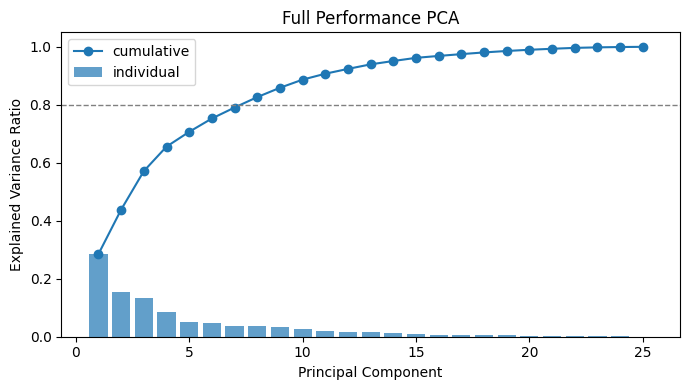

,component,explained_variance_ratio,cumulative_explained_variance_ratio
0,PC1,0.285336,0.285336
1,PC2,0.153114,0.438449
2,PC3,0.132909,0.571358
3,PC4,0.084369,0.655727
4,PC5,0.051060,0.706788
5,PC6,0.045992,0.752779
6,PC7,0.037776,0.790555
7,PC8,0.036009,0.826564
8,PC9,0.032136,0.858700
9,PC10,0.028118,0.886818


,feature,PC1,abs_PC1
11,earned_gpm,0.334678,0.334678
0,golddiffat15,0.315868,0.315868
1,xpdiffat15,0.288223,0.288223
7,dpm,0.287929,0.287929
3,kills,0.279609,0.279609
2,csdiffat15,0.272419,0.272419
8,damage_share,0.253742,0.253742
12,gold_share,0.247879,0.247879
20,aggression_score,0.237056,0.237056
19,objective_control_score,0.231734,0.231734


In [20]:
full_scores, full_loadings, full_variance = run_pca(
    player_patch,
    FULL_FEATURES,
    analysis_name="full_performance_pca",
)

# 분산 시각화
plot_variance(
    full_variance,
    "Full Performance PCA"
)

# 상위 설명력 출력
display(full_variance.head(10))

# PC1 영향 큰 feature 확인
pc1_top = (
    full_loadings[
        ["feature", "PC1"]
    ]
    .assign(abs_PC1=lambda x: x["PC1"].abs())
    .sort_values("abs_PC1", ascending=False)
    .head(10)
)

display(pc1_top)

## 6. 라인전 PCA

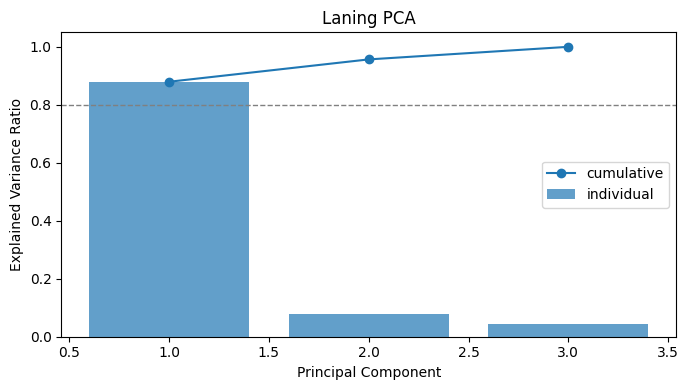

,component,explained_variance_ratio,cumulative_explained_variance_ratio
0,PC1,0.879530,0.879530
1,PC2,0.077088,0.956618
2,PC3,0.043382,1.000000


,feature,PC1,abs_PC1
1,xpdiffat15,0.587086,0.587086
0,golddiffat15,0.578307,0.578307
2,csdiffat15,0.566473,0.566473


,playername,patch,match_count,PC1,PC2
328,Zeka,14.22,3,7.393795,-1.105533
78,Chovy,16.06,7,6.409266,-0.056839
100,FATE,14.22,3,5.610421,1.303082
327,Zeka,14.16,4,5.474075,0.067398
70,Chovy,15.16,3,5.175292,1.038451
297,Ucal,15.21,3,5.080703,-0.580213
339,Zeka,16.11,15,5.033782,-0.824287
337,Zeka,16.08,27,4.544162,-0.088388
81,Chovy,16.09,9,4.399930,-0.188190
255,ShowMaker,14.12,4,4.119433,-0.766749


In [23]:
lane_scores, lane_loadings, lane_variance = run_pca(
    player_patch,
    LANE_FEATURES,
    analysis_name="laning_pca",
)

# 분산 시각화
plot_variance(
    lane_variance,
    "Laning PCA"
)

# 설명력 확인
display(
    lane_variance.head(10)
)

# PC1 주요 feature
lane_pc1 = (
    lane_loadings[
        ["feature", "PC1"]
    ]
    .assign(
        abs_PC1=lambda x: x["PC1"].abs()
    )
    .sort_values(
        "abs_PC1",
        ascending=False
    )
)

display(lane_pc1)

# PC1 높은 선수
display(
    lane_scores
    .sort_values("PC1", ascending=False)
    .head(20)[
        [
            "playername",
            "patch",
            "match_count",
            "PC1",
            "PC2",
        ]
    ]
)

# 평균의 오류해결하기 - 가중평균 

In [24]:
# =========================
# Weighted PC1
# =========================

lane_scores["weighted_PC1"] = (
    lane_scores["PC1"]
    * np.log1p(lane_scores["match_count"])
)

# 상위 확인
display(
    lane_scores
    .sort_values("weighted_PC1", ascending=False)
    .head(20)[
        [
            "playername",
            "patch",
            "match_count",
            "PC1",
            "weighted_PC1",
        ]
    ]
)

,playername,patch,match_count,PC1,weighted_PC1
337,Zeka,16.08,27,4.544162,15.142076
339,Zeka,16.11,15,5.033782,13.956608
78,Chovy,16.06,7,6.409266,13.327695
267,ShowMaker,16.03,54,3.255593,13.046246
328,Zeka,14.22,3,7.393795,10.249977
81,Chovy,16.09,9,4.399930,10.131213
336,Zeka,16.07,24,3.076170,9.901809
0,Bdd,14.12,21,3.132361,9.682261
192,Quad,15.04,16,3.190969,9.040696
327,Zeka,14.16,4,5.474075,8.810184


# 결과해석

# Lane PCA 해석 요약

- 현재 PCA는 15분 이전 라인전 지표만 사용.
- 사용 지표:
  - golddiffat15
  - xpdiffat15
  - csdiffat15
  - goldat15
  - xpat15
  - csat15

------------------------------------------------

PC1:
- 가장 큰 패턴을 설명하는 축.
- 현재 결과상:
  
  "라인전 dominance(체급)"

  를 의미할 가능성이 높음.

- PC1이 높을수록:
  - 골드 우위
  - 경험치 우위
  - CS 우위
  - 초반 성장력

  이 강했다는 뜻.

- 실제로:
  - Chovy
  - Zeka
  - ShowMaker
  - Bdd

  같은 라인전 강자들이 상위에 위치함.

------------------------------------------------

PC2:
- PC1으로 설명되지 않는 두 번째 패턴.
- 보통:
  - 안정 성장형
  - 공격 교전형
  - CS 중심형
  - 킬교환형

  같은 플레이 스타일 차이를 설명.

------------------------------------------------

현재 PCA 의미:
- "누가 잘하냐" 뿐 아니라,
- "어떤 방식으로 라인전을 하는가"

를 잠재 공간(latent space)으로 표현한 것.

# current Skill 지표만들기 (PCA결합 - 현재 폼 점수)

In [12]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# =========================
# LOAD CSV
# =========================

scores = pd.read_csv(
    "./솔랭데이터/full_performance_pca_scores.csv"
)

variance = pd.read_csv(
    "./솔랭데이터/full_performance_pca_variance.csv"
)

# =========================
# 사용할 PC 개수
# =========================

TOP_PCS = 4

# =========================
# variance 기반 weight
# =========================

weights = (
    variance
    .head(TOP_PCS)
    ["explained_variance_ratio"]
)

weights = weights / weights.sum()

# 확인
print(weights)

# =========================
# 사용할 PC 컬럼
# =========================

pc_columns = [
    f"PC{i}"
    for i in range(1, TOP_PCS + 1)
]

# =========================
# CurrentSkill 계산
# =========================

scores["CurrentSkill_raw"] = 0

for pc, weight in zip(
    pc_columns,
    weights
):
    scores["CurrentSkill_raw"] += (
        scores[pc] * weight
    )

# =========================
# 0~100 정규화
# =========================

scaler = MinMaxScaler(
    feature_range=(0, 100)
)

scores["CurrentSkill"] = scaler.fit_transform(
    scores[["CurrentSkill_raw"]]
)

# =========================
# 결과 확인
# =========================

result = (
    scores[
        [
            "playername",
            "patch",
            "CurrentSkill",
            "PC1",
            "PC2",
            "PC3",
            "PC4",
        ]
    ]
    .sort_values(
        "CurrentSkill",
        ascending=False
    )
)

display(result.head(30))

0    0.435144
1    0.233502
2    0.202689
3    0.128665
Name: explained_variance_ratio, dtype: float64


,playername,patch,CurrentSkill,PC1,PC2,PC3,PC4
78,Chovy,16.06,100.000000,9.433823,-0.673933,7.151731,-3.171721
70,Chovy,15.16,98.766957,7.918990,2.546032,1.958674,3.485381
72,Chovy,15.19,82.444188,8.080316,1.496524,-2.303896,0.926767
81,Chovy,16.09,81.148880,4.776845,1.686049,4.297400,0.512183
328,Zeka,14.22,80.372695,10.493598,-5.336178,0.344709,-0.356694
79,Chovy,16.07,78.753094,3.979994,4.079491,2.735004,-0.235827
192,Quad,15.04,77.968589,6.819041,-2.156964,2.855699,0.779327
255,ShowMaker,14.12,75.841279,6.441318,0.110714,-0.498228,1.839196
337,Zeka,16.08,72.030926,7.675958,-1.311764,-0.688281,-1.937486
71,Chovy,15.18,71.955703,6.029688,0.660008,-1.279102,0.933544


| Component | 주요 특징                                            | 간단 해석              |
| --------- | ------------------------------------------------ | ------------------ |
| PC1       | golddiffat15, xpdiffat15, earned_gpm, dpm, kills | 전반적인 체급 및 캐리 성향    |
| PC2       | visionScore, vspm, wpm, vision_aggression        | 시야 장악 및 운영 성향      |
| PC3       | survival_score(+), deaths_per_min(-)             | 안정성 및 생존 중심 성향     |
| PC4       | assists, kp, firstBloodAssist                    | 팀 기여 및 교전 참여 성향    |
| PC5       | wcpm, objective_control_score                    | 와드 활용 및 오브젝트 운영 성향 |
| PC6       | firstBloodKill, aggression_score                 | 초반 공격성 및 교전 주도 성향  |
| PC7       | firstBloodKill 중심                                | 초반 퍼스트블러드 특화 성향    |
| PC8       | firstBloodAssist, tower_damage                   | 오브젝트 및 보조 교전 성향    |


PC1은 골드 수급, 경험치 우위, 딜량 등의 loading이 높게 나타나 전반적인 캐리 및 체급 성향을 반영하는 축으로 해석하였다.

PC2는 visionScore, vspm, wpm 등의 loading이 높게 나타나 시야 장악 및 운영 중심 성향과 관련된 축으로 해석하였다.